# Notebook 01: Maps of GOES observations

## Imports

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pathlib import Path
import matplotlib.colors as mcolors

import warnings
warnings.filterwarnings("ignore")

## Get and prepare data

In [3]:
out_dir = "./plots/"

In [4]:
# ICON grid
grid = xr.open_dataset("./data/grids/hra_DOM01.nc", engine="netcdf4")

lon = np.rad2deg(grid.clon)
lat = np.rad2deg(grid.clat)

# Plot extent
d = 2
lon_min, lon_max = lon.min().item() - d + 1, lon.max().item() + d + 1
lat_min, lat_max = lat.min().item() - d,     lat.max().item() + d

In [5]:
# GOES brightness temperature
BT = xr.open_mfdataset("./data/goes/goes_cropped*.nc")

## Plot data

In [6]:
# Build custom colormap 
def enhanced_colormap(vmin, vmed, vmax, n=256):
    frac = (vmed - vmin) / (vmax - vmin)
    ncol = int(n * frac)

    colors = np.vstack([
        plt.cm.Spectral(np.linspace(0, 0.95, ncol)),
        plt.cm.gray_r(np.linspace(0, 1, n - ncol))
    ])

    return mcolors.LinearSegmentedColormap.from_list("enhanced_colormap", colors)

In [7]:
# Brightness temperature colour scale
vmin, vmed, vmax = -63 + 273.15, -33 + 273.15, 35 + 273.15
levels = np.linspace(vmin, vmax, 201)

cmap = enhanced_colormap(vmin, vmed, vmax)
norm = mcolors.BoundaryNorm(levels, cmap.N)

In [8]:
# Plot settings
start_time = pd.Timestamp("2025-05-30T00:00:00")
times = pd.date_range(start_time, periods=16, freq="30min")

nrows, ncols = 4, 4
lon_fire, lat_fire = -113.8, 56.9

figsize = (11, 10)

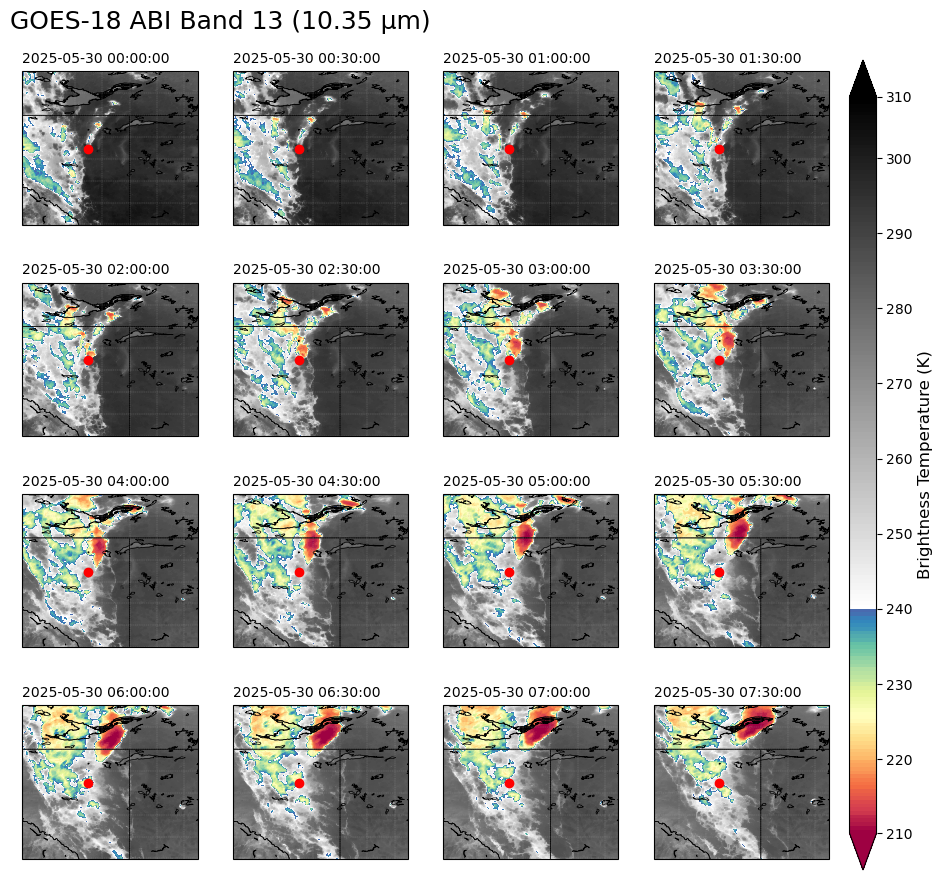

In [9]:
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=figsize,
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.ravel()

for i, ax in enumerate(axes):
    t = times[i]
    data = BT.CMI.sel(t=t, method="nearest") 

    im = ax.contourf(
        BT.longitude, BT.latitude, data,
        transform=ccrs.PlateCarree(),
        cmap=cmap, levels=levels, extend="both"
    )

    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(
        cfeature.LAKES, facecolor="none",
        edgecolor="black", linewidth=0.5
    )
    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    ax.plot(
        lon_fire, lat_fire, "o",
        color="red", markersize=6,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(str(t), fontsize=10, loc="left")
    ax.gridlines(
        draw_labels=False,
        linewidth=0.3,
        linestyle="--",
        alpha=0.5
    )

fig.suptitle(
    "GOES-18 ABI Band 13 (10.35 µm)",
    fontsize=18, y=0.98, x=0.21
)

fig.subplots_adjust(
    left=0.03, right=0.97,
    top=0.93, bottom=0.12,
    wspace=0.2, hspace=0.2
)

cbar = fig.colorbar(
    im, ax=axes,
    orientation="vertical",
    ticks=np.arange(210, 320, 10),
    fraction=0.2, pad=0.02, aspect=30
)
cbar.set_label("Brightness Temperature (K)", fontsize=12)
plt.show()
fig.savefig(out_dir + "goes_bt_map.png", dpi=300, bbox_inches="tight")